In [1]:
import os

import torch
import numpy as np

from flonacomldft.gaussian_utils import MoG
import matplotlib.pyplot as plt

from flonacomldft.models.real_nvp import RealNVP_MLP
from flonacomldft.train_flow_from_data import train_flow

from flonacomldft.full_adaptive_sampling import adaptive_sampling

from flonacomldft.utils.diagnostics import avg_windows
from flonacomldft.utils.plots import set_plot_sequential_data
from matplotlib.pyplot import cm

from ase.units import kB

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import json

/mnt/home/amolina/miniconda3/envs/ml-dft/lib/python3.10/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [31]:
# EMT Results

def load_simulation_info(id_name, isomer, add_part_ratios=False, path=os.getcwd()):
    #id_name = "{:d}{:d}".format(id, i)
    
    file_accs = path + "results_adaptive_is{:d}_{:d}/accs_is{:d}_{:d}.csv".format(isomer, id_name, isomer, id_name)
    df_acc = pd.read_csv(file_accs)
    accs = df_acc[["accs", "time"]].to_numpy()
    
    if add_part_ratios:
        file_part_ratios = path + "results_adaptive_is{:d}_{:d}/part_ratios_is{:d}_{:d}.csv".format(isomer, id_name, isomer, id_name)
        df_part_ratios = pd.read_csv(file_part_ratios)
        part_ratios = df_part_ratios[["part_ratios", "time"]].to_numpy()

    file_args = path + "results_adaptive_is{:d}_{:d}/args_adaptive_sampling_{:d}.json".format(isomer,id_name, id_name)
    f = open(file_args)
    args = json.load(f)
    f.close()
    
    if add_part_ratios:
        return accs, args, part_ratios
    else:
        return accs, args
    

def get_information(ids, path, n_sim, isomer, add_part_ratios=False):
    
    if add_part_ratios:
        all_part_ratios = []
    
    all_accs = []
    all_args = []

    for id_name in ids:
        for j in range(0, n_sim):
            data = load_simulation_info(id_name, isomer=isomer, path=path, add_part_ratios=add_part_ratios)
            all_accs.append(data[0])
            all_args.append(data[1])
            
            if add_part_ratios:
                all_part_ratios.append(data[2])

    md = np.unique([args["folder_path"] for args in all_args])

    hyperparams = ['learning_rate', 'n_iter', 'batch_size', 'n_blocks', 'hidden_dim', 'hidden_depth', 'n_runs', 'n_chains', 'n_steps']
    hyperparams_values = [[] for i in range(len(hyperparams))]

    for i in range(len(hyperparams)):
        for args in all_args:
            hyperparams_values[i].append(args[hyperparams[i]])
            
    hyperparams_values = [np.unique(hyperparams_values[i]) for i in range(len(hyperparams))]
    
    to_return = {'all_accs': all_accs,
                 'all_args': all_args,
                 'hyperparams': hyperparams,
                 'hyperparams_values': hyperparams_values,
                 'isomer': isomer,
                 'md': md,
                }
    
    if add_part_ratios:
        to_return['all_part_ratios'] = all_part_ratios

    
    return to_return

def plot_hyperparams_search_with_ratios(simulation_data, key, ylabel, window=100, upper_bound=0.0):
    
    if 'sims' in simulation_data.keys():
        sims = simulation_data['sims']
    isomer = simulation_data['isomer']
    md = simulation_data['md']
    all_values = simulation_data[key]
    all_args = simulation_data['all_args']
    hyperparams = simulation_data['hyperparams']
    hyperparams_values = simulation_data['hyperparams_values']
    
    fig, axs = plt.subplots(3, 3, figsize=(20, 16))
    fig.subplots_adjust(top=0.92)

    selected_sims = []
    
    axs = axs.ravel()

    for i in range(len(all_values)):
    
        x = all_values[i][:, 1]/3600
        y = all_values[i][:, 0]

        x_avg = avg_windows(x, window, axis=1)
        y_avg = avg_windows(y, window, axis=1)

        if y_avg.max() > upper_bound:
            
            if 'sims' in simulation_data.keys():

                selected_sims.append(sims[i])

            for j in range(len(hyperparams)):
                c = cm.jet(np.linspace(0.1, 0.9, len(hyperparams_values[j])))
                mask = hyperparams_values[j] == all_args[i][hyperparams[j]]
                axs[j].plot(x_avg, y_avg, c=c[mask][0], alpha=0.3, label=hyperparams[j]+"="+str(all_args[i][hyperparams[j]]))

                axs[j].set_title(hyperparams[j])
                axs[j].set_xlabel("MCMC steps")
                axs[j].set_ylabel(ylabel)

                handles, labels = axs[j].get_legend_handles_labels()
                by_label = dict(zip(labels, handles))
                axs[j].legend(by_label.values(), by_label.keys())

    #fig.suptitle("Adaptive MCMC params: \n isomer={} md={}".format(isomer,
                                                                #md[0],) )
    
    return fig, axs, selected_sims

In [32]:
ids = list(range(2534940, 2534946,1)) + list(range(2537206, 2537212,1))
n_sim = 32
isomer = 1
path = "/mnt/home/amolina/ceph/EMT/3-adaptive/results_6/"

ids = [int(str(id_)+str(i)) for i in range(0, n_sim) for id_ in ids]

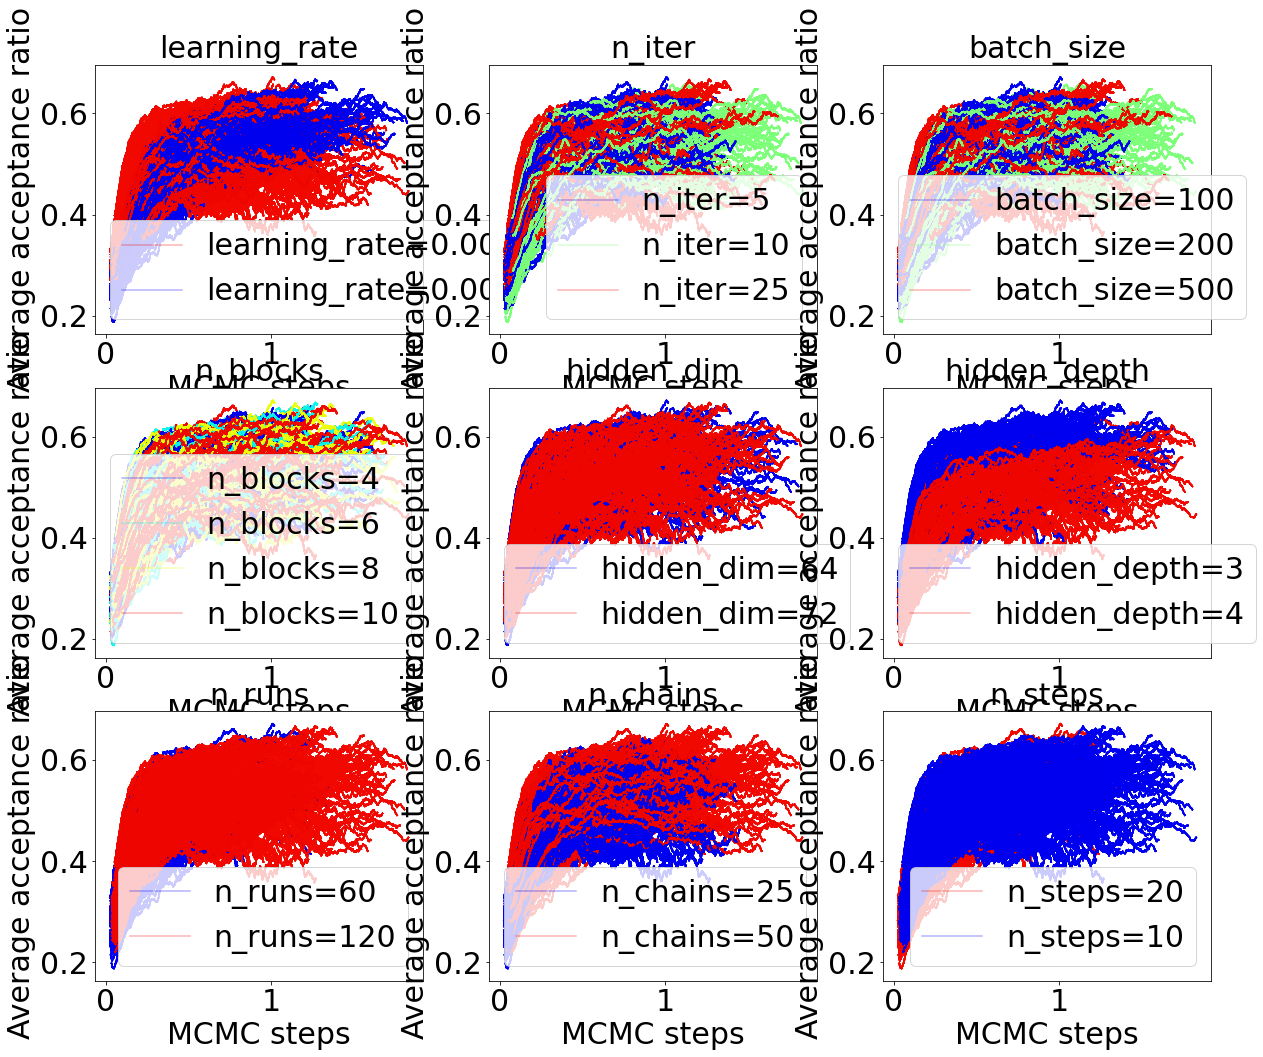

In [33]:
emt_grid_search = get_information(ids, path, n_sim, isomer, add_part_ratios=True)

fig, axs, selected_ids = plot_hyperparams_search_with_ratios(emt_grid_search, "all_accs", "Average acceptance ratio", window=100, upper_bound=0.0);

In [5]:
def get_information_ids(ids, path, n_sim, isomer, add_part_ratios=False):
    
    if add_part_ratios:
        all_part_ratios = []
    
    all_accs = []
    all_args = []
    
    hyperparams = ['learning_rate', 'n_iter', 'batch_size', 'n_blocks', 'hidden_dim', 'hidden_depth', 'n_runs', 'n_chains', 'n_steps']

    sims = []
    
    for id_ in ids:
        data = load_simulation_info(id_, isomer=isomer, path=path, add_part_ratios=add_part_ratios)
        #print(data[1]['n_blocks'], data[1]['hidden_dim'], data[1]['hidden_depth'], data[1]['n_chains'])
        if data[1]['n_blocks']==4 and data[1]['hidden_dim']==64 and data[1]['hidden_depth']==3 and data[1]['n_chains']==50:
            all_accs.append(data[0])
            all_args.append(data[1])
            sims.append(id_)
            
            if add_part_ratios:
                all_part_ratios.append(data[2])

    md = np.unique([args["folder_path"] for args in all_args])

    hyperparams_values = [[] for i in range(len(hyperparams))]

    for i in range(len(hyperparams)):
        for args in all_args:
            hyperparams_values[i].append(args[hyperparams[i]])
            
    hyperparams_values = [np.unique(hyperparams_values[i]) for i in range(len(hyperparams))]
    
    to_return = {'all_accs': all_accs,
                 'all_args': all_args,
                 'hyperparams': hyperparams,
                 'hyperparams_values': hyperparams_values,
                 'isomer': isomer,
                 'md': md,
                 'sims': sims,
                }
    
    if add_part_ratios:
        to_return['all_part_ratios'] = all_part_ratios

    
    return to_return

In [6]:
emt_data = get_information_ids(ids, path, n_sim, isomer, add_part_ratios=True)

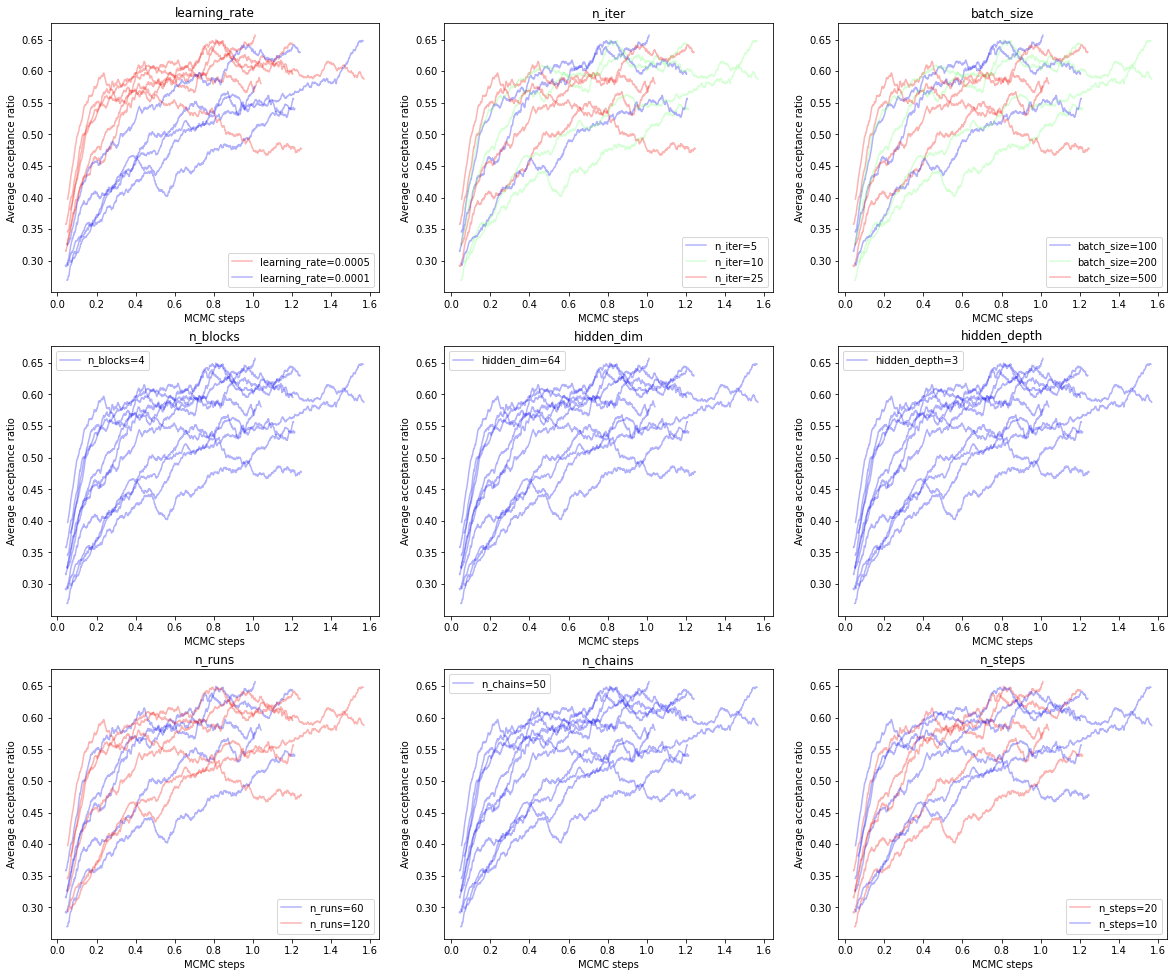

In [7]:
fig, axs, selected_ids = plot_hyperparams_search_with_ratios(emt_data, "all_accs", "Average acceptance ratio", window=100, upper_bound=0.5);

In [8]:
selected_ids

[25372060,
 25372070,
 25372080,
 25372100,
 25372110,
 253720616,
 253720716,
 253720816,
 253720916,
 253721016,
 253721116]

In [9]:
def load_simulation_info(id_name, isomer, add_part_ratios=False, path=os.getcwd()):
    
    file_accs = path + "results_adaptive_is{:d}_{:s}/accs_is{:d}_{:s}.csv".format(isomer, id_name, isomer, id_name)
    df_acc = pd.read_csv(file_accs)
    accs = df_acc[["accs", "time"]].to_numpy()
    
    if add_part_ratios:
        file_part_ratios = path + "results_adaptive_is{:d}_{:s}/part_ratios_is{:d}_{:s}.csv".format(isomer, id_name, isomer, id_name)
        df_part_ratios = pd.read_csv(file_part_ratios)
        part_ratios = df_part_ratios[["part_ratios", "time"]].to_numpy()

    file_args = path + "results_adaptive_is{:d}_{:s}/args_adaptive_sampling_{:s}.json".format(isomer,id_name, id_name)
    f = open(file_args)
    args = json.load(f)
    f.close()
    
    if add_part_ratios:
        return accs, args, part_ratios
    else:
        return accs, args

In [10]:
emt_sims = [load_simulation_info(str(selected_ids[i]), 1, add_part_ratios=True, path=path) for i in range(len(selected_ids))] 

In [11]:
from matplotlib.pyplot import cm
size=30
import matplotlib.pylab as pylab
params = {'legend.fontsize': size,
          'figure.figsize': (15, 5),
         'axes.labelsize': size,
         'axes.titlesize': size,
         'xtick.labelsize': size,
         'ytick.labelsize': size}
pylab.rcParams.update(params)

In [12]:
selected_ids

[25372060,
 25372070,
 25372080,
 25372100,
 25372110,
 253720616,
 253720716,
 253720816,
 253720916,
 253721016,
 253721116]

In [14]:
from flonacomldft.utils.io_utils import load_pickle_file

In [15]:
data = [load_pickle_file("results_adaptive_is1_{:d}/adaptive_sampling_is1_{:d}.pkl".format(selected_ids[i], selected_ids[i]), path) for i in range(len(selected_ids[:-1]))]

In [16]:
def get_accs_ratios(adaptive):
    accs_ratios = torch.stack(adaptive['accs'])
    accs_ratios = accs_ratios.reshape(adaptive['args']['n_steps']*adaptive['args']['n_runs'], adaptive['args']['n_chains'])
    return accs_ratios.mean(dim=1)

In [17]:
def get_part_ratios(adaptive):
    part_ratios = []
    mcmc_steps_part_ratios = []

    flows = adaptive['dict_flows_training']
    n_steps = adaptive['args']['n_steps']

    for i, flow in enumerate(flows):
        part_ratios.append(flow[0]['part_ratios'].mean())
        mcmc_steps_part_ratios.append(n_steps*i)

    return torch.tensor(mcmc_steps_part_ratios), torch.stack(part_ratios)

In [18]:
from matplotlib.ticker import FormatStrFormatter

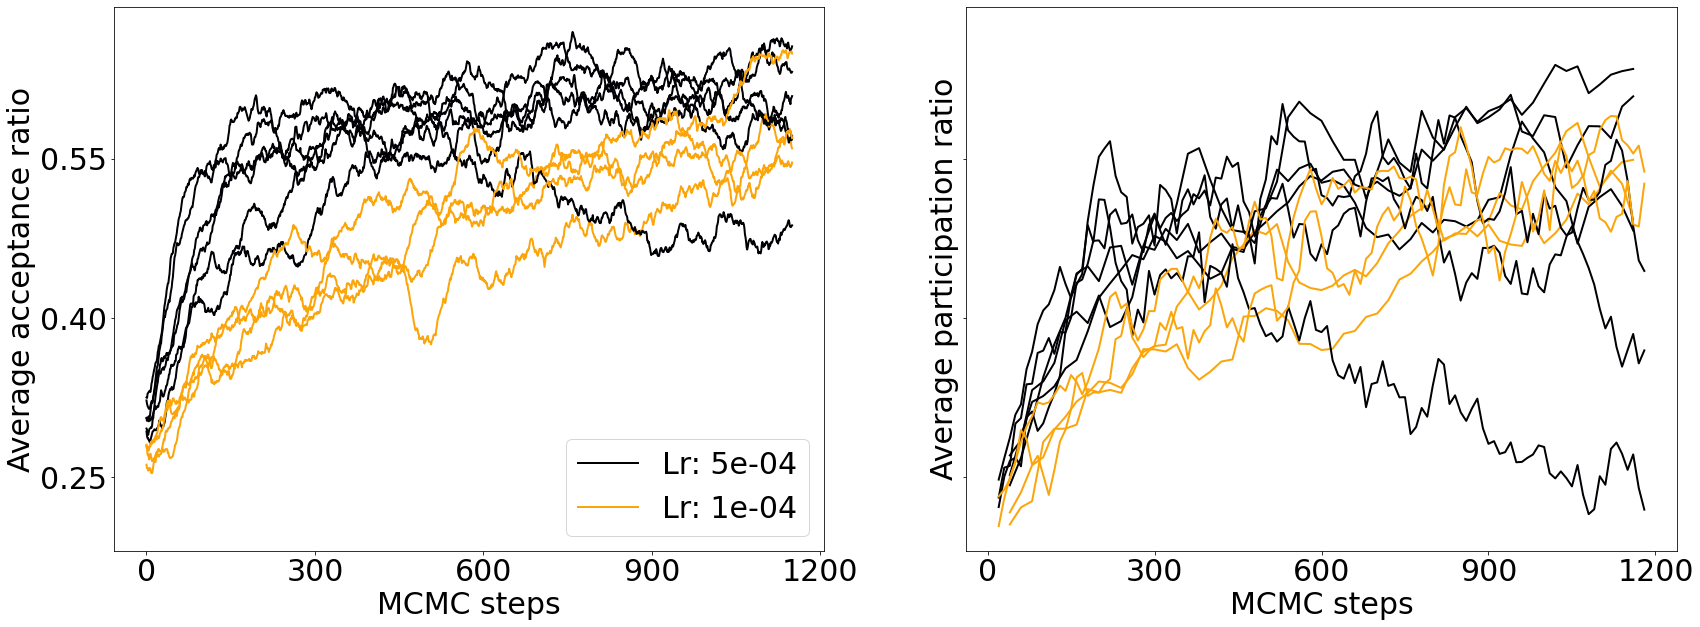

In [19]:
fig, axs = plt.subplots(1, 2, figsize=(28, 10), sharey=True)

color=cm.inferno(np.linspace(0, 0.8, 2))

for i, simulation in enumerate(data):
    accs = get_accs_ratios(simulation)
    accs_avg = avg_windows(accs, 50, axis=1)
    
    n_part_ratios, part_ratios = get_part_ratios(simulation)
    n_part_ratios_avg = avg_windows(n_part_ratios, 5, axis=1)
    part_ratios_avg = avg_windows(part_ratios, 5, axis=1)
           
    hyperparams_label =  'lr: ' + str(emt_sims[i][1]['learning_rate'])
    
    if emt_sims[i][1][hyperparams[0]]==5e-4:
        mask = 0
    else:
        mask = 1
    
    
    axs[0].set_xlabel('MCMC steps')
    axs[0].set_ylabel('Average acceptance ratio')
    
    axs[0].set_xticks(np.linspace(0, 1200, 5))
    axs[0].set_yticks(np.arange(0.25, 0.8, .15), format=FormatStrFormatter('%.1f'))
    
    axs[0].plot(accs_avg, c=color[mask], label='Lr: {:.0e}'.format(simulation['args']['learning_rate']), linewidth=2)

    axs[1].set_xlabel('MCMC steps')
    axs[1].set_ylabel('Average participation ratio')
    
    axs[1].set_xticks(np.linspace(0, 1200, 5))
    axs[1].set_yticks(np.arange(0.25, 0.8, .15), format=FormatStrFormatter('%.1f'))
    

    axs[1].plot(n_part_ratios_avg, part_ratios_avg, c=color[mask], label=simulation['args']['learning_rate'], linewidth=2)

    handles, labels = axs[0].get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    axs[0].legend(by_label.values(), by_label.keys())

In [20]:
path = "/mnt/home/amolina/ceph/ADAPTIVE-DFT/1-adaptive/results_2"

In [21]:
ids = [25072550, 25072551]

In [22]:
data = [load_pickle_file("results_adaptive_is{:d}_{:d}/adaptive_sampling_is{:d}_{:d}.pkl".format(i, ids[i], i, ids[i]), path) for i in range(len(ids))]

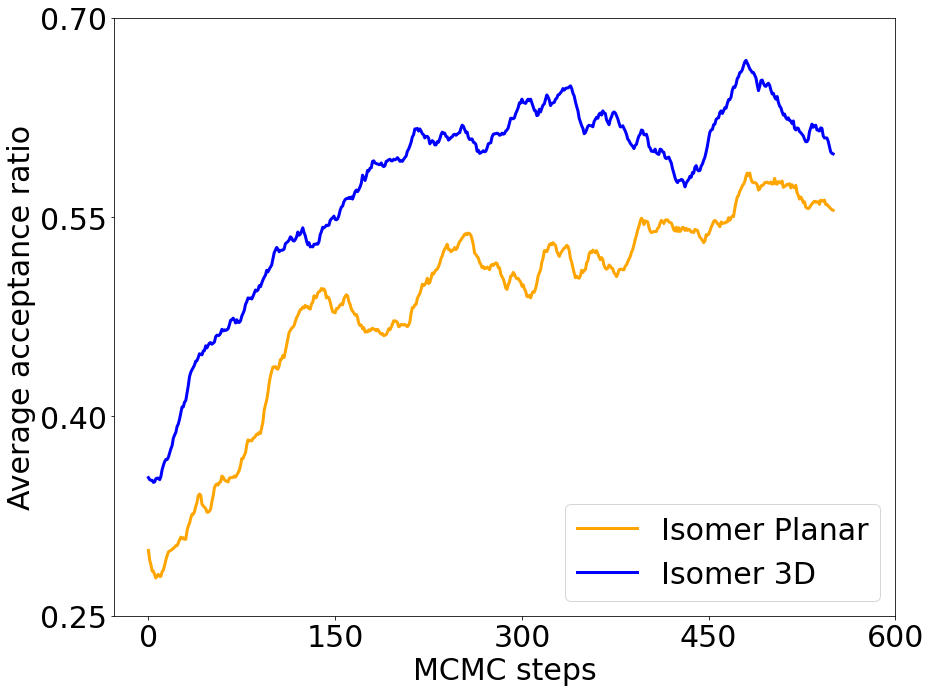

In [23]:
fig, axs = plt.subplots(1, 1, figsize=(14, 11))

c=['orange', 'blue']

names = ["Planar", "3D"]

for i, simulation in enumerate(data):
    accs = get_accs_ratios(simulation)
    accs_avg = avg_windows(accs, 50, axis=1)
    
    hyperlabel = "Isomer {:s}".format(names[i])
    #axs.plot(accs, c=c[i], alpha=0.1)
    axs.plot(accs_avg, c=c[i], label=hyperlabel, linewidth=3)
    
    axs.set_xlabel('MCMC steps')
    axs.set_ylabel('Average acceptance ratio')
    
    axs.set_xticks(np.linspace(0, 600, 5))
    axs.set_yticks(np.arange(0.25, 0.8, .15), format=FormatStrFormatter('%.1f'))
    
axs.legend()

In [24]:
from flonacomldft.utils.io_utils import get_path, load_csv_file

train_is0 = load_csv_file('is0_flow_train.csv', get_path() + '/andersen/datasets')
train_is1 = load_csv_file('is1_flow_train.csv', get_path() + '/andersen/datasets')

In [25]:
energies_md = {'Tridimensional': train_is1[:, 12].detach(),
               'Planar': train_is0[:, 12].detach(),
           }

energies_adaptive = {
    'Tridimensional': torch.stack(data[1]['us']).flatten().detach(),
            'Planar': torch.stack(data[0]['us']).flatten().detach(),
           }

In [26]:
import seaborn as sns

Text(0.5, 0, 'Potential Energy [e.V]')

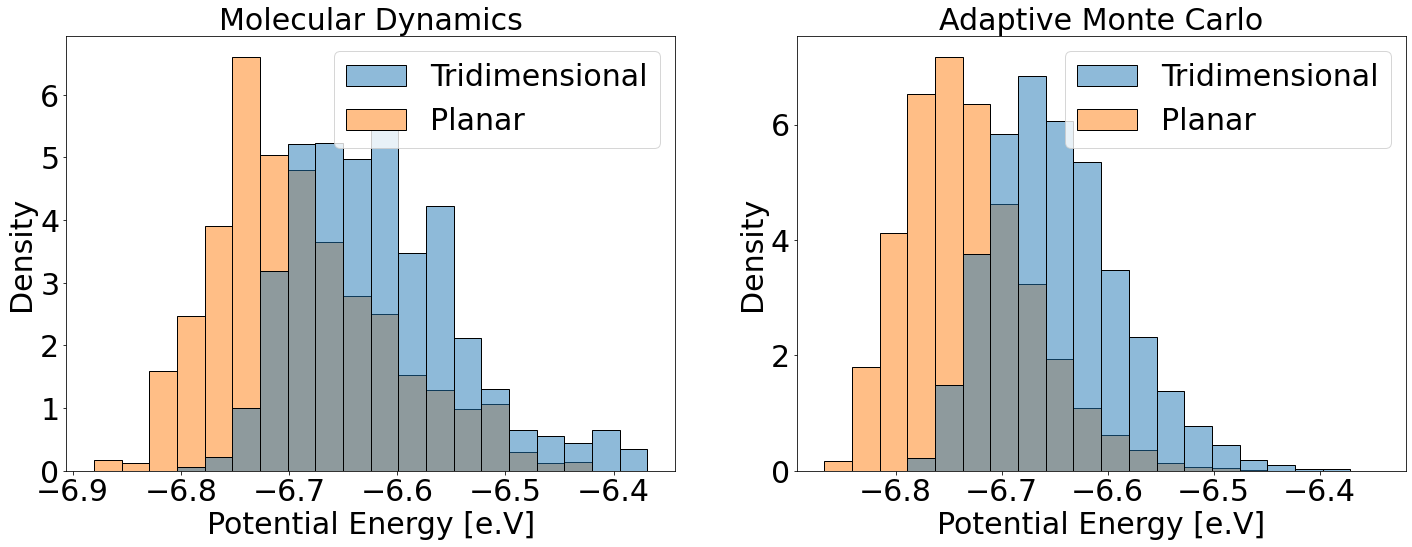

In [27]:
fig, axs = plt.subplots(1, 2, figsize=(24, 8))
sns.histplot(energies_md, stat='density', bins=20, ax=axs[0], common_norm=False)
sns.histplot(energies_adaptive, stat='density', bins=20, ax=axs[1], common_norm=False)

axs[1].set_title('Adaptive Monte Carlo')
axs[0].set_title('Molecular Dynamics')

axs[0].set_xlabel('Potential Energy [e.V]')
axs[1].set_xlabel('Potential Energy [e.V]')

Text(0.5, 0, 'Potential Energy [e.V]')

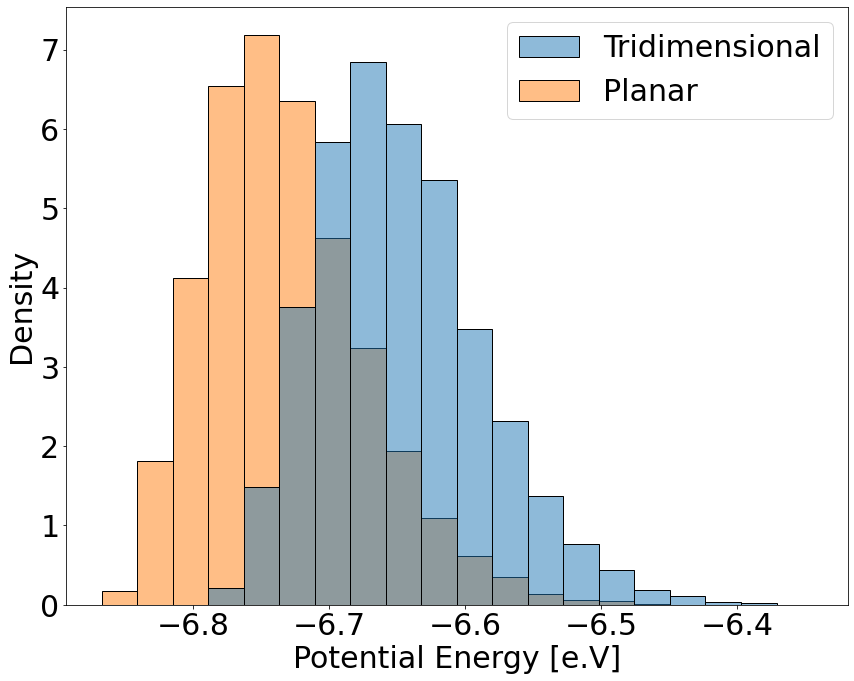

In [30]:
fig, axs = plt.subplots(1, 1, figsize=(14, 11))
sns.histplot(energies_adaptive, stat='density', bins=20, ax=axs, common_norm=False)

axs.set_xlabel('Potential Energy [e.V]')
axs.set_xlabel('Potential Energy [e.V]')